In [6]:
import tensorflow as tf

x = tf.range(-100, 100, 4)
x


<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
        -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
        -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
         32,   36,   40,   44,   48,   52,   56,   60,   64,   68,   72,
         76,   80,   84,   88,   92,   96], dtype=int32)>

In [5]:
y = x + 10
y

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
       -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
        14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
        66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

In [8]:
#lets setup trian and test data agian

x_train = x[:40]
y_train = y [:40]

x_test = x[40:]
y_test = y[40:]

In [26]:
tf.random.set_seed(42)

model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(10, input_shape=[1]),
    tf.keras.layers.Dense(1)
])

model_2.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.SGD(),
                metrics=["mse"])

model_2.fit(x_train, y_train, epochs=100)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 17.9407 - mse: 552.9013 
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 19.5109 - mse: 530.7526
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 20.7316 - mse: 576.8015
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 13.8781 - mse: 295.2726
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 18.3536 - mse: 449.3828
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 13.2915 - mse: 257.5066
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 15.3809 - mse: 323.7483
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 11.2069 - mse: 196.7713
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 15.0474 - mse: 310.8744
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 11.0795 - mse: 193.2014
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 14.9214 - mse: 305.9397
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 11.0307 - mse: 191.5780
Epoch 13/100
2/2 ━━━━━━━

In [30]:
y_pred_2 = model_2.predict(x_test)
y_pred_2

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step


array([[33.85106 ],
       [36.003437],
       [38.155827],
       [40.308205],
       [42.460587],
       [44.612972],
       [46.765354],
       [48.91774 ],
       [51.070118],
       [53.222504]], dtype=float32)

In [27]:
#plot predic function
import matplotlib.pyplot as plt

def plot_predictions(train_data=x_train,
                     train_labels=y_train,
                     test_data=x_test,
                     test_labels=y_test,
                     predictions=y_pred_2):
  """
  plot training data, test data and compares predictions to groun truth labels.

  """

  plt.figure(figsize=(10,7))
  #plot training data in blue
  plt.scatter(train_data, train_labels, c="b", label="training data")
  #plot testing data in green
  plt.scatter(test_data, test_labels, c="g", label="training data")
  #plot model's predictions in red
  plt.scatter(test_data, predictions, c="r", label="predictions")
  plt.legend()

def mae(y_true, y_pred):
  return tf.keras.losses.MAE(y_true=y_true, y_pred=y_pred)

def mse(y_true, y_pred):
  return tf.keras.losses.MSE(y_true=y_true, y_pred=y_pred)

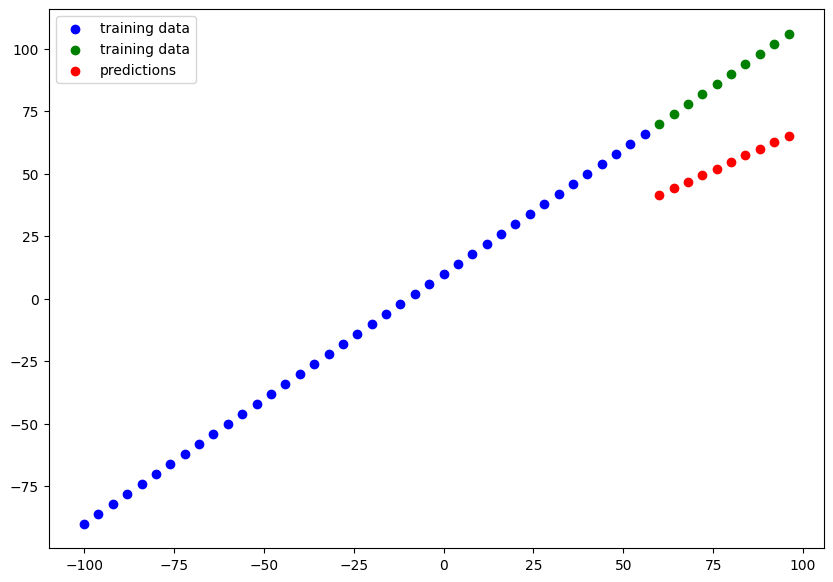

In [28]:
# now lets predict
plot_predictions(predictions=y_pred_2)

In [23]:
#didint get the expected resutl to matc wiht the video but lets move on to next part

mae_2 = mae(y_test, tf.squeeze(y_pred_2))
mae_2

mse_2 = mse(y_test, tf.squeeze(y_pred_2))
mse_2, mae_2

(<tf.Tensor: shape=(), dtype=float32, numpy=1213.0723876953125>,
 <tf.Tensor: shape=(), dtype=float32, numpy=34.608436584472656>)

In [25]:
#lets build the 3rd model

model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(10, input_shape=[1]),
    tf.keras.layers.Dense(1)
])

model_3.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.SGD(),
                metrics=["mae"])

model_3.fit(x_train, y_train, epochs=500)

Epoch 1/500


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 43.1027 - mae: 43.1027 
Epoch 2/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 33.4323 - mae: 33.4323
Epoch 3/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 17.5253 - mae: 17.5253 
Epoch 4/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 19.6801 - mae: 19.6801
Epoch 5/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 17.8287 - mae: 17.8287
Epoch 6/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 17.0767 - mae: 17.0767
Epoch 7/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 11.8087 - mae: 11.8087 
Epoch 8/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 14.6824 - mae: 14.6824
Epoch 9/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 15.5127 - mae: 15.5127 
Epoch 10/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 11.6106 - mae: 11.6106
Epoch 11/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 14.5779 - mae: 14.5779
Epoch 12/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 15.6262 - mae: 15.6262 
Epoch 13/500
2/2 ━━━━━━━━━━━━━

In [ ]:
#now lets visualize

y_pred_3 = model_3.predict(x_test)
plot_predictions(predictions=y_pred_3)

#as you can see in this case we have trinaed the mdoel for too long (this is the model overfitting)

In [34]:
#calculate evaluation metric

mae_3 = mae(y_test, tf.squeeze(y_pred_3))
mse_3 = mse(y_test, tf.squeeze(y_pred_3))
mae_3, mse_3

(<tf.Tensor: shape=(), dtype=float32, numpy=46.336971282958984>,
 <tf.Tensor: shape=(), dtype=float32, numpy=2185.90625>)

In [ ]:
#now lets compare the results of our expreiments (two models here)

#lets compare our model result using a pandas dataframe

import pandas as pd

model_result = [["model_2", mae_2.numpy(), mse_2.numpy()],
                ["model_3", mae_3.numpy(), mse_3.numpy()]]

all_result = pd.DataFrame(model_result, columns=["model", "mae", "mse"])
all_result

In [ ]:
#based on the result looks like model_2 works better

In [ ]:
#how to track your experiets

#on really good habit in macine leaning modelling is to track the result of your experiments

#and when doing so, it can be tedious if you are running lots of expreiments.

#luckily there are tools to help us

# 1. tensorboard = a component of the tensorflow library to help track modelling expreiments
# 2. weights & biases - a tool for tracking all of ml experiments (plugfs stright into tensorboard)

In [ ]:
# next up is to see how to save our model and use it

#saving our model allows us to use them outside of google colab (or whatever they were trained) such as ina web application or mobile application

#there are 2 main formats we can save our model;s too:

  # 1. The SavedModel format
  # 2. the HDF5 format (.h5)



In [42]:
# save a model using savedModel format

model_2.save("newModel.keras")

In [43]:
# save the model wioth h5 format

model_2.save("newHDF5.h5")

In [ ]:
#now lets see how to load te save model and use it
#loading in a saved model

new_model = tf.keras.models.load_model("newModel.keras")
new_model.summary()

In [48]:
#compare model_2 predictions wit savedMOdel format model predictions

model_2_preds = model_2.predict(x_test)
loaded_SavedModel_format_preds = new_model.predict(x_test)
model_2_preds == loaded_SavedModel_format_preds


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step


array([[ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True]])

In [51]:
#noa lets try h5 one :

h5_model = tf.keras.models.load_model("newHDF5.h5")
#h5_model.summary()

h5_model_preds = h5_model.predict(x_test)
h5_model_preds == model_2_preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


array([[ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True]])

In [53]:
#how to donwload a file form colab with code :

from google.colab import files

files.download("newModel.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>